In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# For inline plots in Jupyter
# %matplotlib inline

# ========================================
# CONFIGURATION
# ========================================

INPUT_FILE = "../data/processed/processed.csv"
OUTPUT_DIR = "../utils/analysis"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Configuration loaded!")
print(f"Input file: {INPUT_FILE}")
print(f"Output directory: {OUTPUT_DIR}")

Configuration loaded!
Input file: ../data/processed/processed.csv
Output directory: ../utils/analysis


In [2]:
# -----------------------------------------------------------------------------
# -----------------------------------------------------------------------------
# @title: 2. Load Dataset
# @markdown: Load the dataset for analysis.
# -----------------------------------------------------------------------------
# -----------------------------------------------------------------------------

print("\n" + "="*60)
print("LOADING DATASET")
print("="*60)

df = pd.read_csv(INPUT_FILE)
print(f"✓ Dataset loaded!")
print(f"  - Shape: {df.shape}")
print(f"  - Rows: {df.shape[0]}")
print(f"  - Columns: {df.shape[1]}")

print(f"\n--- Column List ---")
for i, col in enumerate(df.columns):
    print(f"  {i+1}. {col} ({df[col].dtype})")

display(df.head(3))


LOADING DATASET
✓ Dataset loaded!
  - Shape: (4600, 11)
  - Rows: 4600
  - Columns: 11

--- Column List ---
  1. code (object)
  2. bytecode (object)
  3. opcode (object)
  4. label (object)
  5. label_encoded (int64)
  6. cfg (object)
  7. adj_matrix (object)
  8. cfg_dot (object)
  9. cfg_nodes (int64)
  10. cfg_edges (int64)
  11. cfg_density (float64)


,code,bytecode,opcode,label,label_encoded,cfg,adj_matrix,cfg_dot,cfg_nodes,cfg_edges,cfg_density
0,pragma solidity ^0.4.15; // From https://githu...,608060405234801561001057600080fd5b506000806000...,PUSH1 PUSH1 MSTORE CALLVALUE DUP1 ISZERO PUSH2...,unchecked_calls,1,"{'blocks': [[{'address': 0, 'opcode': 'PUSH1',...",[[0. 1. 1. ... 0. 0. 0.]\n [0. 0. 1. ... 0. 0....,digraph CFG {\nrankdir=UD;\nnode [shape=box];\...,503,636,1.264414
1,pragma solidity 0.4.15; /// @title Multisignat...,606060405234156200001057600080fd5b604051620023...,PUSH1 PUSH1 MSTORE CALLVALUE ISZERO PUSH3 JUMP...,unchecked_calls,1,"{'blocks': [[{'address': 0, 'opcode': 'PUSH1',...",[[0. 1. 1. ... 0. 0. 0.]\n [0. 0. 1. ... 0. 0....,digraph CFG {\nrankdir=UD;\nnode [shape=box];\...,644,791,1.228261
2,pragma solidity ^0.4.11; /// @title Multisigna...,60806040523480156200001157600080fd5b5060405162...,PUSH1 PUSH1 MSTORE CALLVALUE DUP1 ISZERO PUSH3...,unchecked_calls,1,"{'blocks': [[{'address': 0, 'opcode': 'PUSH1',...",[[0. 1. 1. ... 0. 0. 0.]\n [0. 0. 1. ... 0. 0....,digraph CFG {\nrankdir=UD;\nnode [shape=box];\...,559,705,1.261181


In [3]:
# -----------------------------------------------------------------------------
# -----------------------------------------------------------------------------
# @title: 3. Basic Statistics
# @markdown: Descriptive statistics of the dataset.
# -----------------------------------------------------------------------------
# -----------------------------------------------------------------------------

print("\n" + "="*60)
print("BASIC STATISTICS")
print("="*60)

# ========================================
# 3.1 Numerical Features Stats
# ========================================
print("\n--- Numerical Features Summary ---")
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols = [c for c in numerical_cols if c not in ['label_encoded']]
print(df[numerical_cols].describe().round(2).T)

# ========================================
# 3.2 Text/Object Features Stats
# ========================================
print("\n--- Text Features Length Stats ---")

# Calculate text lengths
if 'code' in df.columns:
    df['code_length'] = df['code'].str.len()
    print(f"  Code length: min={df['code_length'].min()}, max={df['code_length'].max()}, mean={df['code_length'].mean():.0f}")

if 'bytecode' in df.columns:
    df['bytecode_length'] = df['bytecode'].str.len()
    print(f"  Bytecode length: min={df['bytecode_length'].min()}, max={df['bytecode_length'].max()}, mean={df['bytecode_length'].mean():.0f}")

if 'opcode' in df.columns:
    df['opcode_length'] = df['opcode'].str.len()
    print(f"  Opcode length: min={df['opcode_length'].min()}, max={df['opcode_length'].max()}, mean={df['opcode_length'].mean():.0f}")

# Count opcode tokens
if 'opcode' in df.columns:
    df['opcode_tokens'] = df['opcode'].apply(lambda x: len(str(x).split()) if pd.notna(x) else 0)
    print(f"  Opcode tokens: min={df['opcode_tokens'].min()}, max={df['opcode_tokens'].max()}, mean={df['opcode_tokens'].mean():.0f}")




BASIC STATISTICS

--- Numerical Features Summary ---
              count    mean     std   min    25%     50%     75%      max
cfg_nodes    4600.0  263.37  269.19  3.00  61.00  158.00  412.00  2453.00
cfg_edges    4600.0  321.64  331.74  2.00  71.00  197.00  509.00  3043.00
cfg_density  4600.0    1.18    0.09  0.67   1.17    1.21    1.23     1.31

--- Text Features Length Stats ---
  Code length: min=88, max=646524, mean=11973
  Bytecode length: min=102, max=70974, mean=9009
  Opcode length: min=72, max=108640, mean=13072
  Opcode tokens: min=12, max=18181, mean=2279



CLASS DISTRIBUTION ANALYSIS

--- Label Distribution ---
                 Count  Percentage
label                             
unchecked_calls   2300        50.0
benign            2300        50.0

--- Label Encoded Distribution ---
               Count  Percentage
label_encoded                   
0               2300        50.0
1               2300        50.0

--- Class Balance Check ---
  Largest class: 2300
  Smallest class: 2300
  Imbalance ratio: 1.00:1
  ✓ Dataset is well balanced


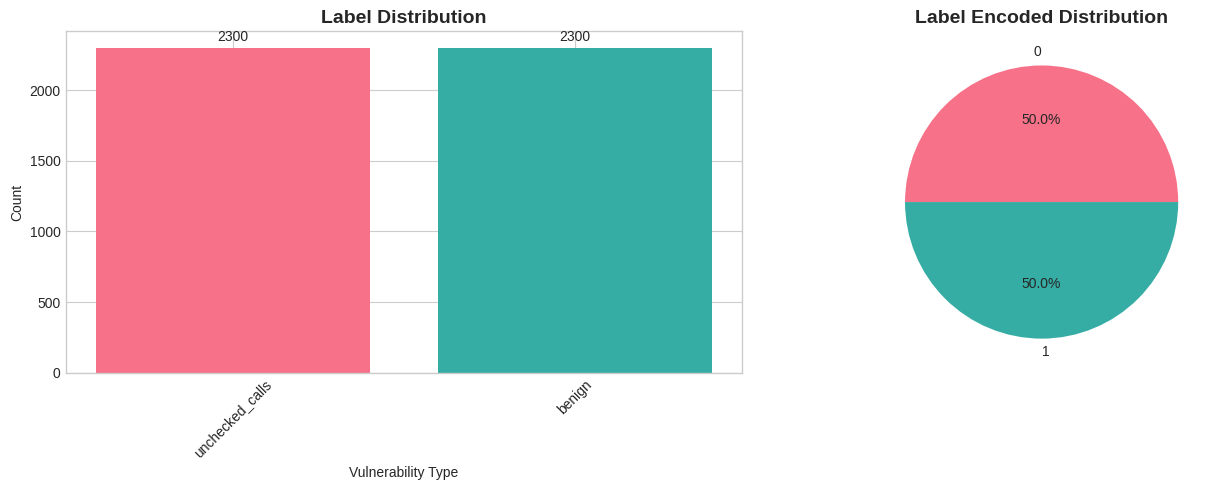

✓ Saved: ../utils/analysis/class_distribution.png


In [4]:
# -----------------------------------------------------------------------------
# -----------------------------------------------------------------------------
# @title: 4. Class Distribution Analysis
# @markdown: Analyze the distribution of labels and encodings.
# -----------------------------------------------------------------------------
# -----------------------------------------------------------------------------

print("\n" + "="*60)
print("CLASS DISTRIBUTION ANALYSIS")
print("="*60)

# ========================================
# 4.1 Label Distribution
# ========================================
print("\n--- Label Distribution ---")
label_counts = df['label'].value_counts()
label_pct = (label_counts / len(df) * 100).round(2)
label_dist = pd.DataFrame({'Count': label_counts, 'Percentage': label_pct})
print(label_dist)

# ========================================
# 4.2 Label Encoded Distribution
# ========================================
print("\n--- Label Encoded Distribution ---")
encoded_counts = df['label_encoded'].value_counts().sort_index()
encoded_pct = (encoded_counts / len(df) * 100).round(2)
encoded_dist = pd.DataFrame({'Count': encoded_counts, 'Percentage': encoded_pct})
print(encoded_dist)

# ========================================
# 4.3 Class Balance Check
# ========================================
print("\n--- Class Balance Check ---")
max_class = label_counts.max()
min_class = label_counts.min()
balance_ratio = max_class / min_class
print(f"  Largest class: {max_class}")
print(f"  Smallest class: {min_class}")
print(f"  Imbalance ratio: {balance_ratio:.2f}:1")

if balance_ratio <= 1.5:
    print("  ✓ Dataset is well balanced")
elif balance_ratio <= 3:
    print("  ⚠ Dataset has mild imbalance")
else:
    print("  ✗ Dataset has severe imbalance")

# ========================================
# 4.4 Visualization - Class Distribution
# ========================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart - Labels
colors = sns.color_palette("husl", len(label_counts))
axes[0].bar(label_counts.index, label_counts.values, color=colors)
axes[0].set_title("Label Distribution", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Vulnerability Type")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=45)

# Add count labels
for i, (label, count) in enumerate(label_counts.items()):
    axes[0].text(i, count + 50, str(count), ha='center', fontsize=10)

# Pie chart - Label Encoded
axes[1].pie(encoded_counts.values, labels=encoded_counts.index, autopct='%1.1f%%', 
            colors=sns.color_palette("husl", len(encoded_counts)))
axes[1].set_title("Label Encoded Distribution", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/class_distribution.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {OUTPUT_DIR}/class_distribution.png")


FEATURE DISTRIBUTION ANALYSIS

--- CFG Metrics Statistics ---
              count    mean     std   min    25%     50%     75%      max
cfg_nodes    4600.0  263.37  269.19  3.00  61.00  158.00  412.00  2453.00
cfg_edges    4600.0  321.64  331.74  2.00  71.00  197.00  509.00  3043.00
cfg_density  4600.0    1.18    0.09  0.67   1.17    1.21    1.23     1.31

--- Code Length by Label ---
                     mean       std  min     max
label                                           
benign           11916.09  42164.60   88  646524
unchecked_calls  12029.42  13236.99   90   92874

--- Bytecode Length by Label ---
                     mean       std  min    max
label                                          
benign            6868.30   7279.78  102  70974
unchecked_calls  11148.86  10122.39  168  49038

--- Opcode Tokens by Label ---
                    mean      std  min    max
label                                        
benign           1677.78  1868.51   12  18181
unchecked_calls  28

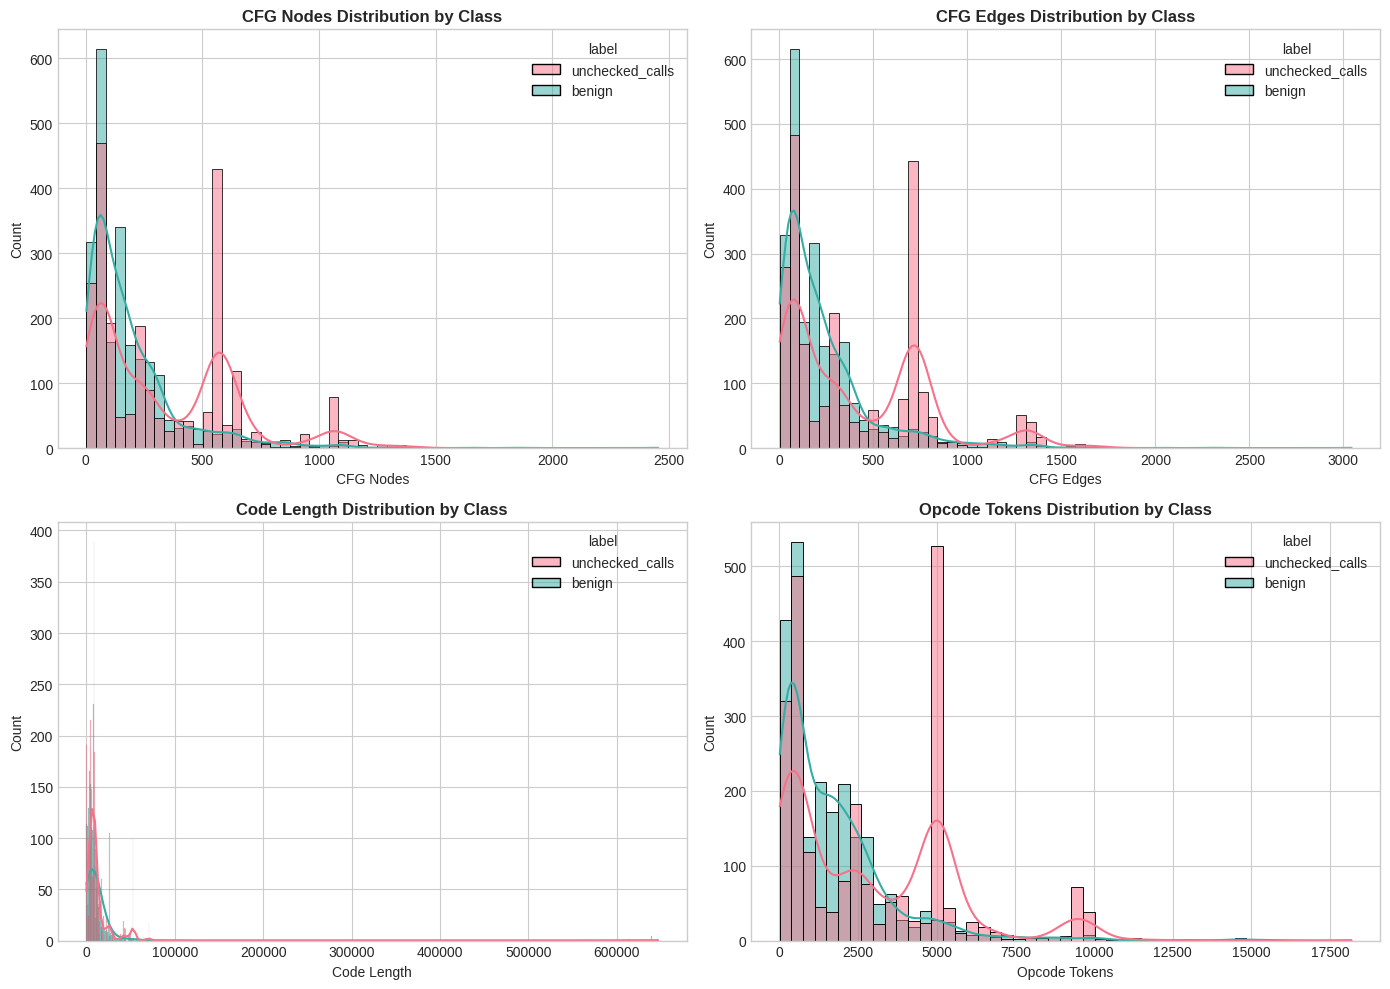

✓ Saved: ../utils/analysis/feature_distributions.png


In [5]:
# -----------------------------------------------------------------------------
# -----------------------------------------------------------------------------
# @title: 5. Feature Distribution Analysis
# @markdown: Analyze the distribution of numerical features.
# -----------------------------------------------------------------------------
# -----------------------------------------------------------------------------

print("\n" + "="*60)
print("FEATURE DISTRIBUTION ANALYSIS")
print("="*60)

# ========================================
# 5.1 CFG Metrics Stats
# ========================================
print("\n--- CFG Metrics Statistics ---")
cfg_metrics = ['cfg_nodes', 'cfg_edges', 'cfg_density']
cfg_stats = df[cfg_metrics].describe().round(2)
print(cfg_stats.T)

# ========================================
# 5.2 Code Length Stats by Class
# ========================================
print("\n--- Code Length by Label ---")
if 'code_length' in df.columns:
    code_by_label = df.groupby('label')['code_length'].agg(['mean', 'std', 'min', 'max']).round(2)
    print(code_by_label)

print("\n--- Bytecode Length by Label ---")
if 'bytecode_length' in df.columns:
    bytecode_by_label = df.groupby('label')['bytecode_length'].agg(['mean', 'std', 'min', 'max']).round(2)
    print(bytecode_by_label)

print("\n--- Opcode Tokens by Label ---")
if 'opcode_tokens' in df.columns:
    opcode_by_label = df.groupby('label')['opcode_tokens'].agg(['mean', 'std', 'min', 'max']).round(2)
    print(opcode_by_label)

# ========================================
# 5.3 Visualization - Feature Distributions
# ========================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# CFG Nodes distribution
sns.histplot(data=df, x='cfg_nodes', hue='label', kde=True, ax=axes[0, 0], palette="husl")
axes[0, 0].set_title("CFG Nodes Distribution by Class", fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel("CFG Nodes")

# CFG Edges distribution
sns.histplot(data=df, x='cfg_edges', hue='label', kde=True, ax=axes[0, 1], palette="husl")
axes[0, 1].set_title("CFG Edges Distribution by Class", fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel("CFG Edges")

# Code Length distribution
if 'code_length' in df.columns:
    sns.histplot(data=df, x='code_length', hue='label', kde=True, ax=axes[1, 0], palette="husl")
    axes[1, 0].set_title("Code Length Distribution by Class", fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel("Code Length")

# Opcode Tokens distribution
if 'opcode_tokens' in df.columns:
    sns.histplot(data=df, x='opcode_tokens', hue='label', kde=True, ax=axes[1, 1], palette="husl")
    axes[1, 1].set_title("Opcode Tokens Distribution by Class", fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel("Opcode Tokens")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/feature_distributions.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {OUTPUT_DIR}/feature_distributions.png")


FEATURE COMPARISON BY CLASS


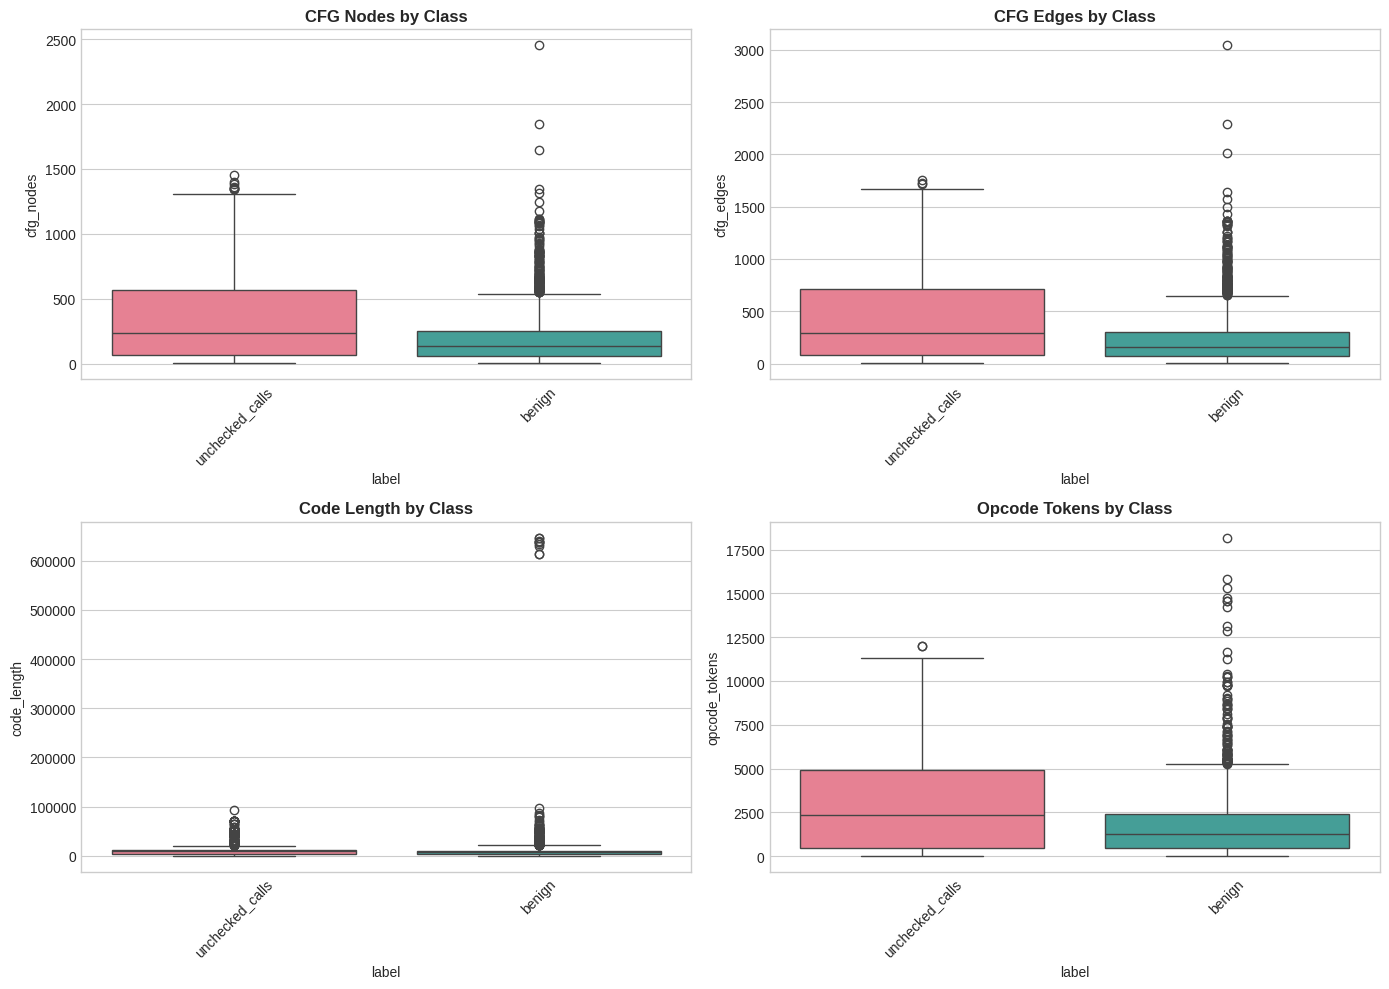

✓ Saved: ../utils/analysis/feature_boxplots.png

--- Feature Statistics by Class ---
                cfg_nodes                cfg_edges                cfg_density  \
                     mean     std median      mean     std median        mean   
label                                                                           
benign             189.93  205.71  135.0    230.77  253.27  161.0        1.17   
unchecked_calls    336.80  303.08  240.5    412.51  373.48  293.0        1.19   

                             code_length                   opcode_tokens  \
                  std median        mean       std  median          mean   
label                                                                      
benign           0.10   1.20    11916.09  42164.60  7283.5       1677.78   
unchecked_calls  0.07   1.22    12029.42  13236.99  9044.0       2879.98   

                                  
                     std  median  
label                             
benign           1868.5

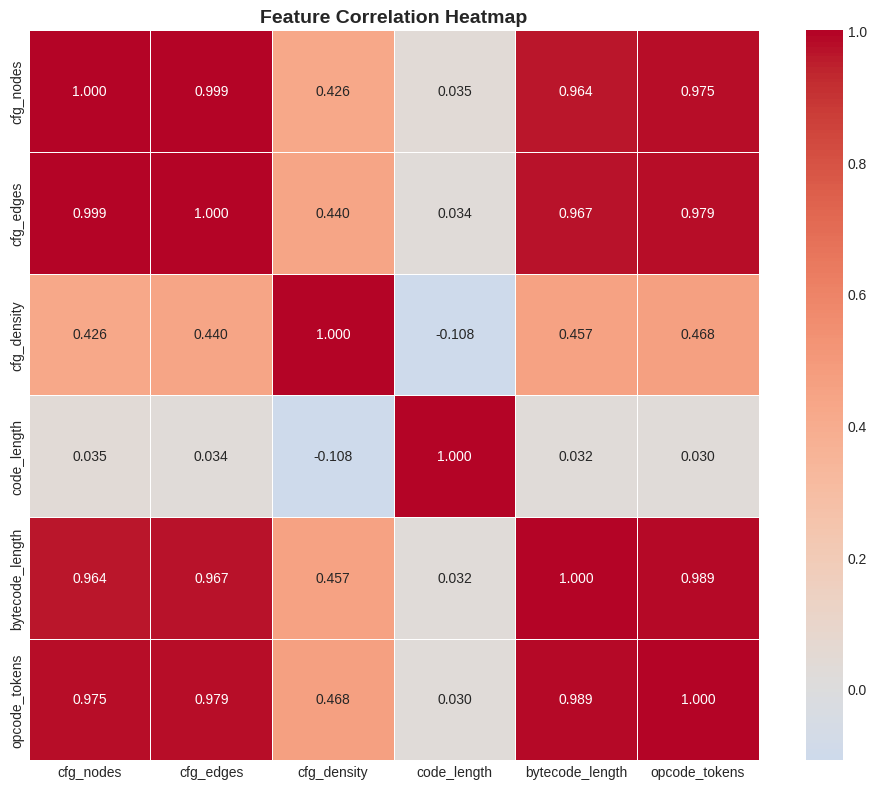

✓ Saved: ../utils/analysis/correlation_heatmap.png


In [6]:
# -----------------------------------------------------------------------------
# -----------------------------------------------------------------------------
# @title: 6. Box Plots - Feature Comparison by Class
# @markdown: Compare features across different vulnerability classes.
# -----------------------------------------------------------------------------
# -----------------------------------------------------------------------------

print("\n" + "="*60)
print("FEATURE COMPARISON BY CLASS")
print("="*60)

# ========================================
# Visualization - Box Plots
# ========================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# CFG Nodes boxplot
sns.boxplot(data=df, x='label', y='cfg_nodes', ax=axes[0, 0], palette="husl")
axes[0, 0].set_title("CFG Nodes by Class", fontsize=12, fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)

# CFG Edges boxplot
sns.boxplot(data=df, x='label', y='cfg_edges', ax=axes[0, 1], palette="husl")
axes[0, 1].set_title("CFG Edges by Class", fontsize=12, fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)

# Code Length boxplot
if 'code_length' in df.columns:
    sns.boxplot(data=df, x='label', y='code_length', ax=axes[1, 0], palette="husl")
    axes[1, 0].set_title("Code Length by Class", fontsize=12, fontweight='bold')
    axes[1, 0].tick_params(axis='x', rotation=45)

# Opcode Tokens boxplot
if 'opcode_tokens' in df.columns:
    sns.boxplot(data=df, x='label', y='opcode_tokens', ax=axes[1, 1], palette="husl")
    axes[1, 1].set_title("Opcode Tokens by Class", fontsize=12, fontweight='bold')
    axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/feature_boxplots.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {OUTPUT_DIR}/feature_boxplots.png")

# ----------------------------------------
# Statistical Summary by Class
# ----------------------------------------
print("\n--- Feature Statistics by Class ---")
feature_stats = df.groupby('label')[cfg_metrics + ['code_length', 'opcode_tokens']].agg(['mean', 'std', 'median']).round(2)
print(feature_stats)

# -----------------------------------------------------------------------------
# -----------------------------------------------------------------------------
# @title: 7. Correlation Analysis
# @markdown: Analyze correlations between numerical features.
# -----------------------------------------------------------------------------
# -----------------------------------------------------------------------------

print("\n" + "="*60)
print("CORRELATION ANALYSIS")
print("="*60)

# ========================================
# Correlation Matrix
# ========================================
numerical_features = ['cfg_nodes', 'cfg_edges', 'cfg_density']
if 'code_length' in df.columns:
    numerical_features.append('code_length')
if 'bytecode_length' in df.columns:
    numerical_features.append('bytecode_length')
if 'opcode_tokens' in df.columns:
    numerical_features.append('opcode_tokens')

corr_matrix = df[numerical_features].corr()

print("\n--- Correlation Matrix ---")
print(corr_matrix.round(3))

# ========================================
# Visualization - Heatmap
# ========================================

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.3f', linewidths=0.5, square=True)
plt.title("Feature Correlation Heatmap", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/correlation_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {OUTPUT_DIR}/correlation_heatmap.png")

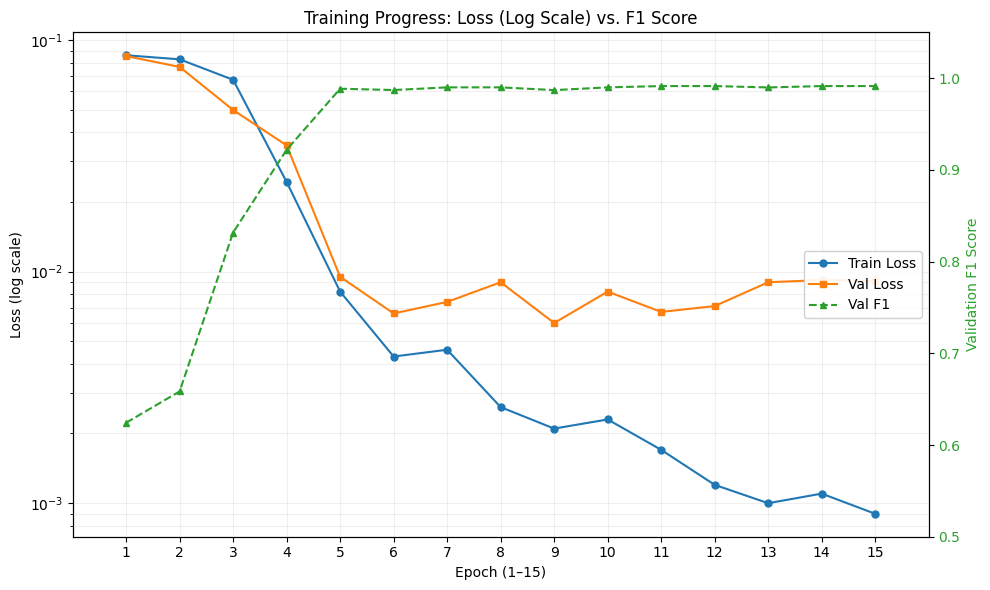

In [1]:
 import matplotlib.pyplot as plt
import numpy as np

# --- 1. Data Preparation ---
epochs = np.arange(1, 16)

train_loss = [
    0.0860, 0.0826, 0.0674, 0.0244, 0.0082, 0.0043, 0.0046, 
    0.0026, 0.0021, 0.0023, 0.0017, 0.0012, 0.0010, 0.0011, 
    0.0009
]

val_loss = [
    0.0853, 0.0766, 0.0499, 0.0351, 0.0095, 0.0066, 0.0074, 
    0.0090, 0.0060, 0.0082, 0.0067, 0.0071, 0.0090, 0.0092, 
    0.0091
]

val_f1 = [
    0.6243, 0.6584, 0.8317, 0.9219, 0.9885, 0.9871, 0.9900, 
    0.9900, 0.9870, 0.9900, 0.9914, 0.9914, 0.9899, 0.9914, 
    0.9914
]

# --- 2. Plotting ---
fig, ax1 = plt.subplots(figsize=(10, 6))

# Set X-axis ticks
ax1.set_xticks(epochs)
ax1.set_xlim(0, 16)

# --- Left Y-Axis: Loss (Log Scale) ---
ax1.set_xlabel('Epoch (1–15)')
ax1.set_ylabel('Loss (log scale)', color='black')
ax1.set_yscale('log') # Applying log scale as suggested

# Plot Train Loss
line1, = ax1.plot(epochs, train_loss, label='Train Loss', color='tab:blue', linestyle='-', marker='o', markersize=5)

# Plot Val Loss
line2, = ax1.plot(epochs, val_loss, label='Val Loss', color='tab:orange', linestyle='-', marker='s', markersize=5)

ax1.tick_params(axis='y', labelcolor='black')
ax1.grid(True, which="both", ls="-", alpha=0.2)

# --- Right Y-Axis: F1 Score ---
ax2 = ax1.twinx()

ax2.set_ylabel('Validation F1 Score', color='tab:green')
ax2.set_ylim(0.5, 1.05) # F1 typically ranges 0 to 1

# Plot F1 Score
line3, = ax2.plot(epochs, val_f1, label='Val F1', color='tab:green', linestyle='--', marker='^', markersize=5)

ax2.tick_params(axis='y', labelcolor='tab:green')

# --- 3. Legend and Title ---
lines = [line1, line2, line3]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='center right', framealpha=0.9)

plt.title('Training Progress: Loss (Log Scale) vs. F1 Score')
plt.tight_layout()

plt.show()

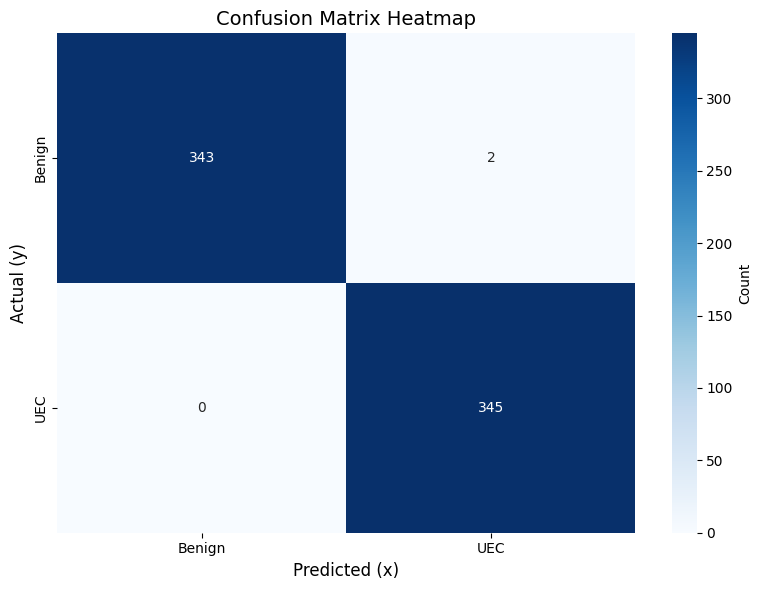

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 1. Data Preparation ---
# (Based on your provided values: TN=343, FP=2, FN=0, TP=345)
# Note: 
# Matrix layout (Rows: Actual, Cols: Predicted) -> [[TN, FP], [FN, TP]]
cm = np.array([[343, 2], 
               [0, 345]])

labels = ['Benign', 'UEC'] # Both Actual and Predicted classes

# --- 2. Plotting ---
plt.figure(figsize=(8, 6))

# Create heatmap
# annot=True displays the numbers, fmt='d' formats them as integers, 
# cmap='Blues' gives a nice color scheme
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels,
            cbar_kws={'label': 'Count'})

# --- 3. Labels and Title ---
plt.title('Confusion Matrix Heatmap', fontsize=14)
plt.xlabel('Predicted (x)', fontsize=12) # X-axis
plt.ylabel('Actual (y)', fontsize=12)    # Y-axis

plt.tight_layout()
plt.show()

TLOS Vulnerability Localization
Classification : unchecked_calls
Confidence     : 0.8356
Raw Logit      : 1.6261

Decoded Function Selectors
------------------------------------------------------------
0x04fef1db   -> getUtilisation(address)
0x07c58752   -> MAX_LIQUIDATION_FEE_USD()
0x0842b076   -> allWhitelistedTokensLength()
0x0a48d5a9   -> tokenToUsdMin(address,uint256)
0x10eb56c2   -> stableTaxBasisPoints()
0x126082cf   -> BASIS_POINTS_DIVISOR()
0x12d43a51   -> gov()


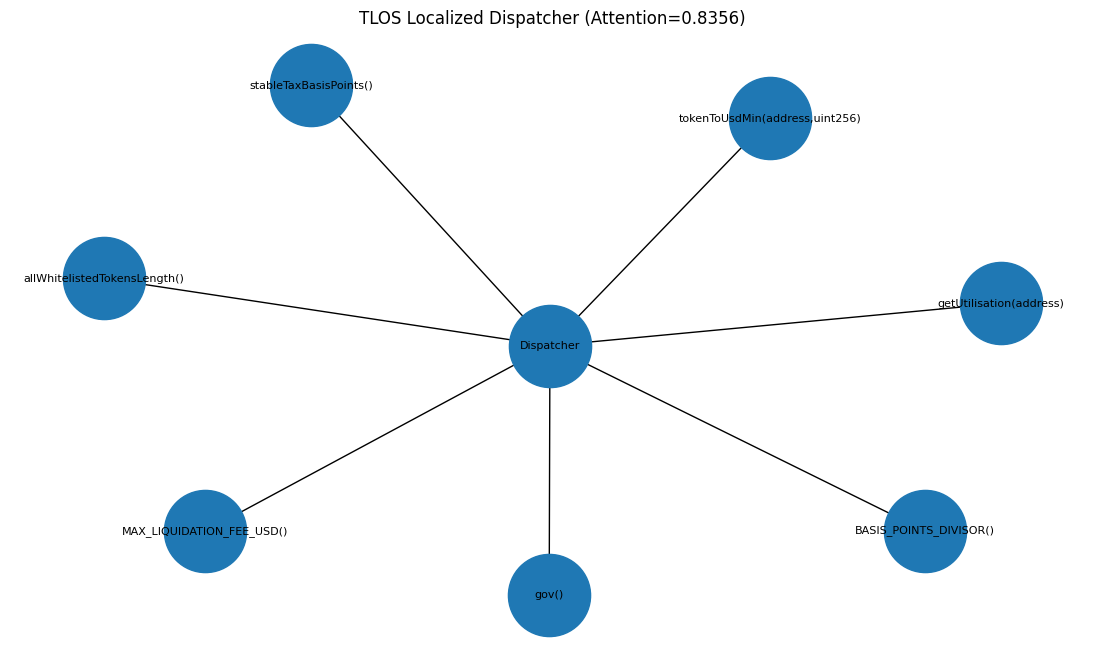

In [4]:
import json
import requests
import networkx as nx
import matplotlib.pyplot as plt

# --------------------------------------------------
# Load JSON
# --------------------------------------------------
file_name = "gmx/opcode.tlos"
target_path = f"examples/{file_name}.json"

with open(target_path, "r") as f:
    data = json.load(f)

node = data["high_attention_subgraph"]["nodes"][0]

attention = node["attention_fusion_score"]
opcodes = node["opcode_trace"]

print("=" * 60)
print("TLOS Vulnerability Localization")
print("=" * 60)

print(
    f"Classification : "
    f"{data['vulnerability_metrics']['classification']}"
)

print(
    f"Confidence     : "
    f"{data['vulnerability_metrics']['confidence_score']:.4f}"
)

print(
    f"Raw Logit      : "
    f"{data['vulnerability_metrics']['raw_logit']:.4f}"
)

print()

# --------------------------------------------------
# Resolve PUSH4 selectors using 4byte Directory
# --------------------------------------------------

def resolve_selector(selector):

    selector = selector.lower()

    url = (
        "https://www.4byte.directory/api/v1/signatures/"
        f"?hex_signature={selector}"
    )

    try:

        r = requests.get(
            url,
            timeout=10
        )

        if r.status_code == 200:

            results = r.json()["results"]

            if len(results):

                return results[0]["text_signature"]

    except Exception:
        pass

    return "UNKNOWN"


decoded_selectors = []

for i, op in enumerate(opcodes):

    if op == "PUSH4":

        selector = opcodes[i + 1]

        signature = resolve_selector(selector)

        decoded_selectors.append(
            (selector, signature)
        )

print("Decoded Function Selectors")
print("-" * 60)

for selector, sig in decoded_selectors:

    print(
        f"{selector:<12} -> {sig}"
    )

# --------------------------------------------------
# Build Dispatcher Graph
# --------------------------------------------------

G = nx.DiGraph()

dispatcher = "Dispatcher"

G.add_node(
    dispatcher,
    attention=attention
)

for selector, sig in decoded_selectors:

    G.add_node(sig)

    G.add_edge(
        dispatcher,
        sig
    )

# --------------------------------------------------
# Visualization
# --------------------------------------------------

plt.figure(
    figsize=(14, 8)
)

pos = nx.spring_layout(
    G,
    seed=42
)

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=3500
)

nx.draw_networkx_edges(
    G,
    pos,
    arrows=True
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=8
)

plt.title(
    f"TLOS Localized Dispatcher "
    f"(Attention={attention:.4f})"
)

plt.axis("off")

plt.show()

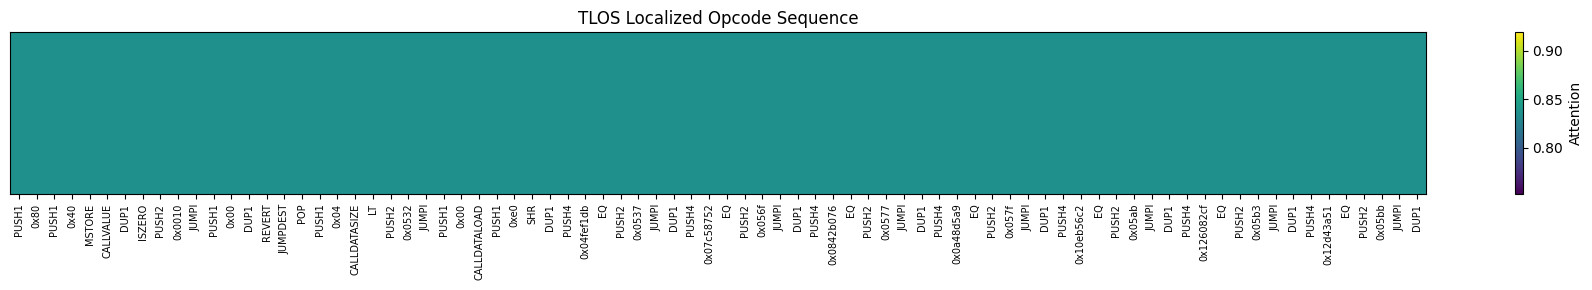

In [5]:
import numpy as np
import matplotlib.pyplot as plt

scores = np.ones(len(opcodes))

scores *= attention

plt.figure(
    figsize=(18, 3)
)

plt.imshow(
    [scores],
    aspect="auto"
)

plt.yticks([])

plt.xticks(
    range(len(opcodes)),
    opcodes,
    rotation=90,
    fontsize=7
)

plt.colorbar(
    label="Attention"
)

plt.title(
    "TLOS Localized Opcode Sequence"
)

plt.tight_layout()

plt.show()

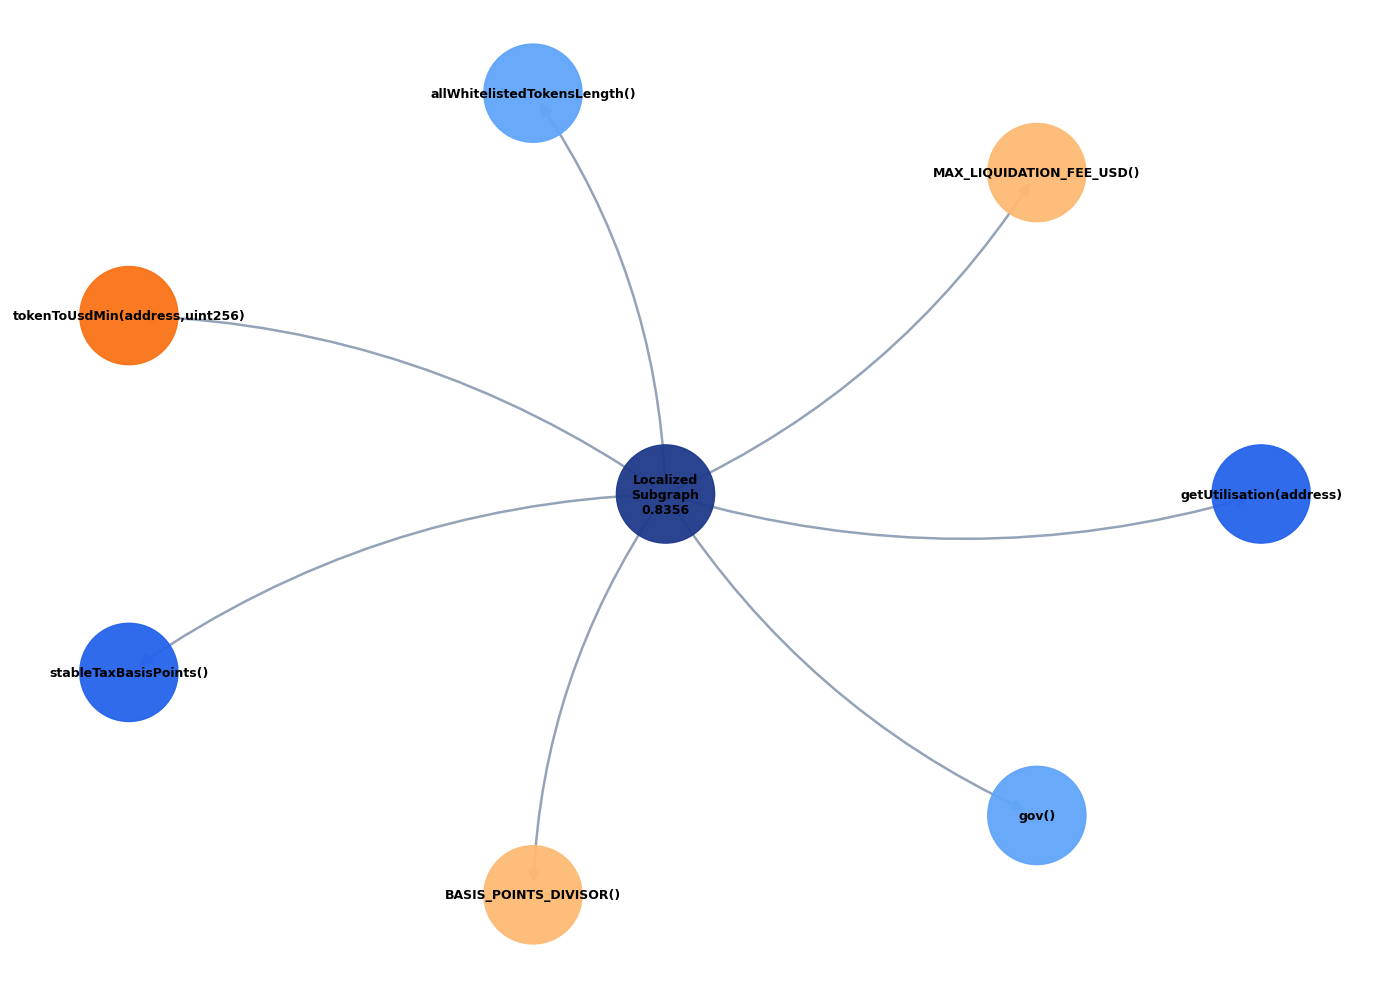

In [7]:
import json
import requests
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# --------------------------------------------------
# Load JSON
# --------------------------------------------------
file_name = "gmx/opcode.tlos"
target_path = f"examples/{file_name}.json"

with open(target_path, "r") as f:
    data = json.load(f)

node = data["high_attention_subgraph"]["nodes"][0]

attention = node["attention_fusion_score"]
opcodes = node["opcode_trace"]

# --------------------------------------------------
# 4byte lookup
# --------------------------------------------------

def resolve_selector(selector):

    url = (
        "https://www.4byte.directory/api/v1/signatures/"
        f"?hex_signature={selector.lower()}"
    )

    try:
        r = requests.get(url, timeout=10)

        if r.status_code == 200:

            results = r.json()["results"]

            if len(results):

                return results[0]["text_signature"]

    except Exception:
        pass

    return selector

# --------------------------------------------------
# Extract selectors
# --------------------------------------------------

decoded = []

for i, op in enumerate(opcodes):

    if op == "PUSH4":

        selector = opcodes[i + 1]

        decoded.append(
            (
                selector,
                resolve_selector(selector)
            )
        )

# --------------------------------------------------
# Build graph
# --------------------------------------------------

G = nx.DiGraph()

center_node = (
    f"Localized\nSubgraph\n{attention:.4f}"
)

G.add_node(center_node)

for selector, signature in decoded:

    G.add_node(signature)

    G.add_edge(
        center_node,
        signature
    )

# --------------------------------------------------
# Nice colors
# --------------------------------------------------

orange_palette = [
    "#f97316",
    "#fb923c",
    "#fdba74",
    "#fed7aa"
]

blue_palette = [
    "#1d4ed8",
    "#2563eb",
    "#3b82f6",
    "#60a5fa"
]

node_colors = []

function_nodes = list(G.nodes())[1:]

for idx, node_name in enumerate(G.nodes()):

    if node_name == center_node:

        node_colors.append("#1e3a8a")

    else:

        if idx % 2 == 0:
            node_colors.append(
                orange_palette[
                    idx % len(orange_palette)
                ]
            )

        else:
            node_colors.append(
                blue_palette[
                    idx % len(blue_palette)
                ]
            )

# --------------------------------------------------
# Layout
# --------------------------------------------------

pos = nx.circular_layout(G)

pos[center_node] = [0, 0]

scale = 2.0

for i, node_name in enumerate(function_nodes):

    angle = (
        2 * 3.14159265 * i
        / len(function_nodes)
    )

    pos[node_name] = [
        scale * np.cos(angle),
        scale * np.sin(angle)
    ]

# --------------------------------------------------
# Plot
# --------------------------------------------------

plt.figure(
    figsize=(14, 10)
)

nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    node_size=5000,
    alpha=0.95
)

nx.draw_networkx_edges(
    G,
    pos,
    edge_color="#94a3b8",
    width=1.8,
    arrows=True,
    arrowsize=18,
    connectionstyle="arc3,rad=0.15"
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=9,
    font_weight="bold"
)

plt.axis("off")

plt.tight_layout()

plt.show()

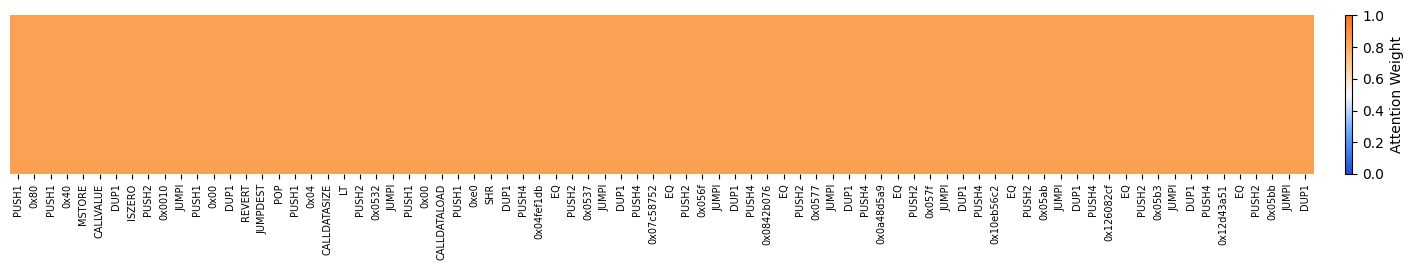

In [9]:
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# --------------------------------------------------
# Load JSON
# --------------------------------------------------

with open(target_path, "r") as f:
    data = json.load(f)

node = data["high_attention_subgraph"]["nodes"][0]

attention = node["attention_fusion_score"]
opcodes = node["opcode_trace"]

# --------------------------------------------------
# Generate attention values
#
# Replace this with actual per-opcode attention
# when available.
# --------------------------------------------------

scores = np.ones(len(opcodes)) * attention

# --------------------------------------------------
# Blue → Orange paper-friendly colormap
# --------------------------------------------------

cmap = LinearSegmentedColormap.from_list(
    "tlos",
    [
        "#1d4ed8",   # blue
        "#60a5fa",   # light blue
        "#f8fafc",   # neutral
        "#fdba74",   # light orange
        "#f97316"    # orange
    ]
)

# --------------------------------------------------
# Figure
# --------------------------------------------------

fig, ax = plt.subplots(
    figsize=(16, 2.8)
)

heatmap = ax.imshow(
    [scores],
    cmap=cmap,
    aspect="auto",
    vmin=0,
    vmax=1
)

# --------------------------------------------------
# Opcode labels
# --------------------------------------------------

ax.set_xticks(
    np.arange(len(opcodes))
)

ax.set_xticklabels(
    opcodes,
    rotation=90,
    fontsize=7
)

ax.set_yticks([])

# --------------------------------------------------
# Remove frame
# --------------------------------------------------

for spine in ax.spines.values():
    spine.set_visible(False)

# --------------------------------------------------
# Colorbar
# --------------------------------------------------

cbar = plt.colorbar(
    heatmap,
    pad=0.02
)

cbar.set_label(
    "Attention Weight",
    fontsize=10
)

# --------------------------------------------------
# Clean layout
# --------------------------------------------------

plt.tight_layout()

# --------------------------------------------------
# Export publication figure
# --------------------------------------------------

plt.savefig(
    "tlos_heatmap.pdf",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "tlos_heatmap.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

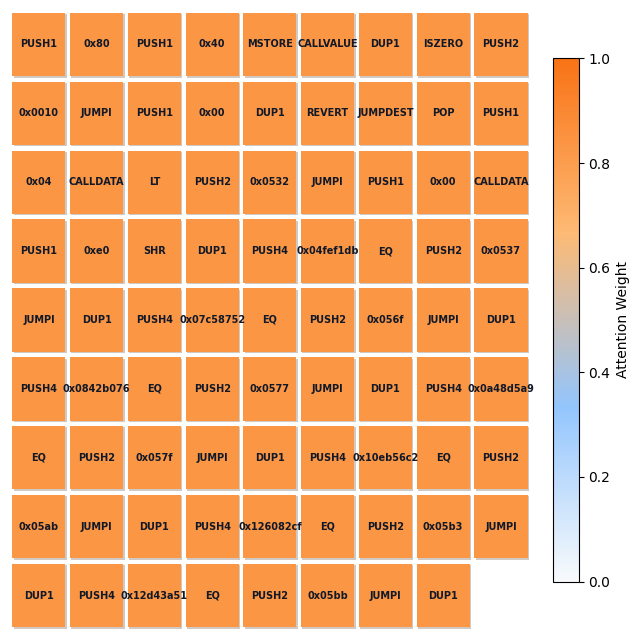

In [25]:
import json
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle
import matplotlib.patheffects as pe

# --------------------------------------------------
# Load data
# --------------------------------------------------

with open(target_path, "r") as f:
    data = json.load(f)

node = data["high_attention_subgraph"]["nodes"][0]
opcodes = node["opcode_trace"]

# --------------------------------------------------
# Attention (block-level broadcast)
# --------------------------------------------------

attention_score = node["attention_fusion_score"]
scores = np.ones(len(opcodes)) * attention_score

# --------------------------------------------------
# Grid setup
# --------------------------------------------------

n = len(scores)
grid_size = math.ceil(np.sqrt(n))

# --------------------------------------------------
# Colormap (paper-grade blue → orange)
# --------------------------------------------------

cmap = LinearSegmentedColormap.from_list(
    "tlos",
    ["#f8fafc", "#93c5fd", "#fdba74", "#f97316"]
)

# --------------------------------------------------
# Figure
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(6.5, 6.5))

ax.set_xlim(0, grid_size)
ax.set_ylim(0, grid_size)
ax.invert_yaxis()

gap = 0.08  # spacing between squares

# --------------------------------------------------
# Draw opcode grid with shadows
# --------------------------------------------------

for i in range(n):

    r = i // grid_size
    c = i % grid_size

    val = scores[i]
    color = cmap(val)

    rect = Rectangle(
        (c + gap / 2, r + gap / 2),
        1 - gap,
        1 - gap,
        facecolor=color,
        edgecolor="none"
    )

    # soft shadow effect
    rect.set_path_effects([
        pe.SimplePatchShadow(offset=(1, -1), alpha=0.25),
        pe.Normal()
    ])

    ax.add_patch(rect)

    opcode = opcodes[i]
    label = opcode if len(opcode) <= 10 else opcode[:8]

    ax.text(
        c + 0.5,
        r + 0.5,
        label,
        ha="center",
        va="center",
        fontsize=7,
        fontweight="bold",
        color="#111827"
    )

# --------------------------------------------------
# Clean axes
# --------------------------------------------------

ax.set_xticks([])
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(False)

# --------------------------------------------------
# FIXED COLORBAR (THIS RESOLVES YOUR ERROR)
# --------------------------------------------------

norm = mpl.colors.Normalize(vmin=0, vmax=1)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)

cbar.set_label(
    "Attention Weight",
    fontsize=10
)

# --------------------------------------------------
# Layout
# --------------------------------------------------

plt.tight_layout()
plt.show()

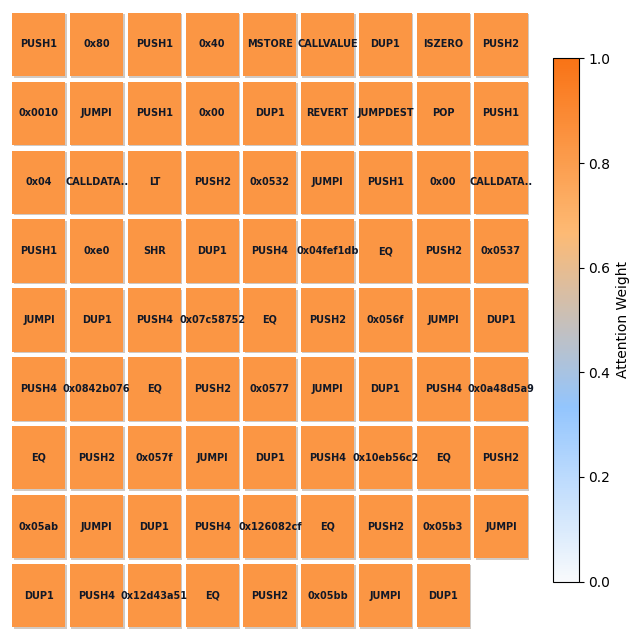

In [26]:
import json
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle
import matplotlib.patheffects as pe

# --------------------------------------------------
# Load data
# --------------------------------------------------

with open(target_path, "r") as f:
    data = json.load(f)

node = data["high_attention_subgraph"]["nodes"][0]
opcodes = node["opcode_trace"]

# --------------------------------------------------
# Attention Logic
# --------------------------------------------------

attention_score = node["attention_fusion_score"]

# Safety check: Ensure score is interpreted as a float. 
# If your model outputs raw large numbers, normalize this value:
# Example: normalized_score = attention_score / (max_score_seen)
score = float(attention_score) 
if score > 1.0: 
    # Clamp to 1 if raw score is larger (visualization fix)
    score = 1.0 

scores = np.ones(len(opcodes)) * score

# --------------------------------------------------
# Grid Setup
# --------------------------------------------------

n = len(scores)
grid_size = math.ceil(np.sqrt(n))

# --------------------------------------------------
# Colormap (Blue -> Orange gradient)
# --------------------------------------------------

cmap = LinearSegmentedColormap.from_list(
    "tlos",
    ["#f8fafc", "#93c5fd", "#fdba74", "#f97316"]
)

# --------------------------------------------------
# Figure Setup
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(6.5, 6.5))

ax.set_xlim(0, grid_size)
ax.set_ylim(0, grid_size)
ax.invert_yaxis()

gap = 0.08

# --------------------------------------------------
# Draw Grid with Shadows
# --------------------------------------------------

for i in range(n):
    r = i // grid_size
    c = i % grid_size

    val = scores[i]
    # Get RGBA color from colormap
    rgba_color = cmap(val)

    # Draw Rectangle
    rect = Rectangle(
        (c + gap / 2, r + gap / 2),
        1 - gap,
        1 - gap,
        facecolor=rgba_color,
        edgecolor="none"
    )
    
    # Add soft shadow
    rect.set_path_effects([
        pe.SimplePatchShadow(offset=(1, -1), alpha=0.25),
        pe.Normal()
    ])
    
    ax.add_patch(rect)

    # Add Text
    opcode = opcodes[i]
    label = opcode if len(opcode) <= 10 else opcode[:8] + ".."
    
    ax.text(
        c + 0.5, r + 0.5,
        label,
        ha="center", va="center",
        fontsize=7, fontweight="bold",
        color="#111827"
    )

# --------------------------------------------------
# Clean Axes
# --------------------------------------------------

ax.set_xticks([])
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(False)

# --------------------------------------------------
# FIXED COLORBAR
# --------------------------------------------------

# 1. Create a Normalize object based on the data range (0 to 1)
norm = mpl.colors.Normalize(vmin=0.0, vmax=1.0)

# 2. Initialize ScalarMappable with the norm and the custom cmap
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

# 3. Set empty array (required for older matplotlib versions)
sm.set_array([])

# 4. Draw the colorbar
cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Attention Weight", fontsize=10)

# --------------------------------------------------
# Layout
# --------------------------------------------------

plt.tight_layout()
plt.show()